In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Defining Tickers
all_tickers=['SPY','QQQ','TLT','LQD','VNQ','SCHH']

In [3]:
#Cleaning Data
data=yf.download(all_tickers, start="2010-01-01", end="2026-05-01")['Close']
data=data.dropna()

/tmp/ipykernel_1106/3794698722.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download(all_tickers, start="2010-01-01", end="2026-05-01")['Close']
[*********************100%***********************]  6 of 6 completed


In [4]:
#Obtaining the log-returns
returns=np.log(data/data.shift(1)).dropna()

In [5]:
returns.describe()

Ticker,LQD,QQQ,SCHH,SPY,TLT,VNQ
count,3845.000000,3845.000000,3845.000000,3845.000000,3845.000000,3845.000000
mean,0.000140,0.000676,0.000268,0.000518,0.000092,0.000301
std,0.004858,0.013060,0.012812,0.010808,0.009406,0.012621
min,-0.051325,-0.127592,-0.200641,-0.115887,-0.069011,-0.195136
25%,-0.002114,-0.004808,-0.005537,-0.003685,-0.005601,-0.005423
50%,0.000395,0.001198,0.000930,0.000699,0.000516,0.000835
75%,0.002542,0.007397,0.006791,0.005772,0.005692,0.006857
max,0.071314,0.113356,0.088938,0.099863,0.072503,0.087131


In [6]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.9 MB/s eta 0:00:00


In [7]:
from arch import arch_model

In [8]:
#Applying GARCH(1,1) model, zt~t-student
std_returns = pd.DataFrame(index=returns.index)
for ticker in all_tickers:
    ticker_return = returns[ticker] * 100
    model = arch_model(ticker_return, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    model_fitted = model.fit(disp='off')
    std_returns[ticker] = model_fitted.resid / model_fitted.conditional_volatility

In [9]:
std_returns.describe()

,SPY,QQQ,TLT,LQD,VNQ,SCHH
count,3845.000000,3845.000000,3845.000000,3845.000000,3845.000000,3845.000000
mean,-0.072980,-0.072727,-0.005043,-0.032588,-0.047539,-0.046420
std,0.993804,0.988981,1.001440,1.001983,0.998527,0.998179
min,-5.983610,-5.053952,-6.300923,-6.079077,-5.406139,-5.324396
25%,-0.583872,-0.568654,-0.665829,-0.638153,-0.616518,-0.621813
50%,-0.032051,-0.013671,0.044647,0.025530,0.006701,0.018053
75%,0.560317,0.543374,0.658678,0.590939,0.600013,0.606293
max,3.533749,4.411011,4.464769,5.803701,5.009696,4.887103


In [10]:
#Constructing the correlation matrix
std_returns.corr(method='pearson')

,SPY,QQQ,TLT,LQD,VNQ,SCHH
SPY,1.000000,0.912965,-0.236031,0.095873,0.609121,0.589274
QQQ,0.912965,1.000000,-0.182074,0.111166,0.483356,0.461237
TLT,-0.236031,-0.182074,1.000000,0.802372,0.060203,0.052544
LQD,0.095873,0.111166,0.802372,1.000000,0.303722,0.290872
VNQ,0.609121,0.483356,0.060203,0.303722,1.000000,0.990933
SCHH,0.589274,0.461237,0.052544,0.290872,0.990933,1.000000


In [11]:
#Applying the empirical probability integral transform and preparing the data for copula fitting
from scipy.stats import rankdata

uniform_data = pd.DataFrame(index=std_returns.index)

for ticker in std_returns.columns:
    n = len(std_returns[ticker])
    uniform_data[ticker] = rankdata(std_returns[ticker])/(n+1)


print(uniform_data.head(), uniform_data.tail())
print(uniform_data.agg(['min', 'max']))

                 SPY       QQQ       TLT       LQD       VNQ      SCHH
Date                                                                  
2011-01-14  0.830473  0.771971  0.207228  0.063703  0.761050  0.835933
2011-01-18  0.558242  0.581643  0.273271  0.391576  0.833333  0.784711
2011-01-19  0.073323  0.091264  0.817733  0.368435  0.065263  0.078263
2011-01-20  0.362715  0.177587  0.042382  0.077743  0.469319  0.513001
2011-01-21  0.594124  0.165367  0.827613  0.648986  0.494020  0.576443                  SPY       QQQ       TLT       LQD       VNQ      SCHH
Date                                                                  
2026-04-24  0.816433  0.959438  0.596464  0.542382  0.378835  0.380135
2026-04-27  0.554342  0.472959  0.204368  0.191888  0.249870  0.267031
2026-04-28  0.202028  0.160166  0.540822  0.508580  0.831773  0.849454
2026-04-29  0.435777  0.691628  0.096724  0.053042  0.179927  0.224909
2026-04-30  0.926157  0.806552  0.422257  0.588404  0.952678  0.950858
      

In [12]:
!pip install copulae

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.1
    Uninstalling wrapt-2.2.1:
      Successfully uninstalled wrapt-2.2.1


In [13]:
from copulae.archimedean import ClaytonCopula

In [14]:
#Fitting a clayton copula to every pairwise of assets
import itertools

tickers = uniform_data.columns
n_assets = len(tickers)

tail_dep_matrix = pd.DataFrame(1.0, index=tickers, columns=tickers)

for tick1, tick2 in itertools.combinations(tickers, 2):

    u1 = uniform_data[tick1]
    u2 = uniform_data[tick2]
    pair_data = np.column_stack((u1, u2))

    clayton = ClaytonCopula(dim=2)
    try:
        clayton.fit(pair_data)
        theta = clayton.params

        if theta <= 0.001:
            lambda_L = 0
        else:
            lambda_L = 2 ** (-1 / theta)

    except:
        lambda_L = 0.0

    tail_dep_matrix.loc[tick1, tick2] = lambda_L
    tail_dep_matrix.loc[tick2, tick1] = lambda_L

print("MATRIZ DE DEPENDENCIA DE COLA INFERIOR (CRISIS)")
print(tail_dep_matrix.round(4))

MATRIZ DE DEPENDENCIA DE COLA INFERIOR (CRISIS)
         SPY     QQQ     TLT     LQD     VNQ    SCHH
SPY   1.0000  0.8277  0.0000  0.0014  0.5007  0.4805
QQQ   0.8277  1.0000  0.0000  0.0027  0.3647  0.3409
TLT   0.0000  0.0000  1.0000  0.7370  0.0042  0.0025
LQD   0.0014  0.0027  0.7370  1.0000  0.1614  0.1453
VNQ   0.5007  0.3647  0.0042  0.1614  1.0000  0.9528
SCHH  0.4805  0.3409  0.0025  0.1453  0.9528  1.0000


In [15]:
from scipy.linalg import eigh
#Obtaining the eigenvalues of the dependence matrix
eigenvalues = eigh(tail_dep_matrix.values, eigvals_only=True)

eigenvalues = np.sort(eigenvalues)[::-1]
#if any eigenvalue is < 0 we make that eigenvalue ≈ 0
if np.all(eigenvalues >= 0):
  eigenvalues_used=eigenvalues
else:
  eigenvalues_used = np.clip(eigenvalues, a_min=1e-10, a_max=None)

eigenvalues_normalized = eigenvalues_used / np.sum(eigenvalues_used)

entropy = -np.sum(eigenvalues_normalized * np.log(eigenvalues_normalized + 1e-12))

effective_assets = np.exp(entropy)

print(f"Number of assets: {len(tail_dep_matrix)}")
print(f"Number of EFFECTIVE assets under crises: {effective_assets:.2f}")
print(f"Diversification efficiency under crises {effective_assets/len(tail_dep_matrix)*100:.2f}%")




Number of assets: 6
Number of EFFECTIVE assets under crises: 3.62
Diversification efficiency under crises 60.29%


In [16]:
pearson_matrix=std_returns.corr(method='pearson')

In [17]:
#Obtaining Shannon Entropy of Pearson Matrix
#Notice that Pearson Matrix is a correlation matrix -> the matrix is PSD -> eigenvalues >= 0 -> No clipping

eigenvalues_p = eigh(pearson_matrix.values, eigvals_only=True)
eigenvalues_p = np.sort(eigenvalues_p)[::-1]

eigenvalues_pnorm=eigenvalues_p/np.sum(eigenvalues_p)

entropy_p = -np.sum(eigenvalues_pnorm * np.log(eigenvalues_pnorm + 1e-12))

activos_efectivos_p = np.exp(entropy_p)

print(f"Number of assets: {len(pearson_matrix)}")
print(f"Number of effective assets: {activos_efectivos_p:.2f}")
print(f"Diversification efficiency {activos_efectivos_p/len(pearson_matrix)*100:.2f}%" )



Number of assets: 6
Number of effective assets: 3.07
Diversification efficiency 51.17%


In [18]:
#Obtaining the eigenvalues and normalized eigenvalues of each matrix

print(eigenvalues_p)
print(eigenvalues_pnorm)

print(eigenvalues)
print(eigenvalues_normalized)

[3.105245   1.88066047 0.79402893 0.14283658 0.06863563 0.00859339]
[0.51754083 0.31344341 0.13233816 0.0238061  0.01143927 0.00143223]
[2.75839623 1.73934745 1.05153065 0.24873168 0.15557437 0.04641962]
[0.4597327  0.28989124 0.17525511 0.04145528 0.02592906 0.0077366 ]


<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1106/2617629211.py:62: SyntaxWarning: invalid escape sequence '\l'
  cbar_kws={"label": "Lower-tail dependence ($\lambda_L$)"},


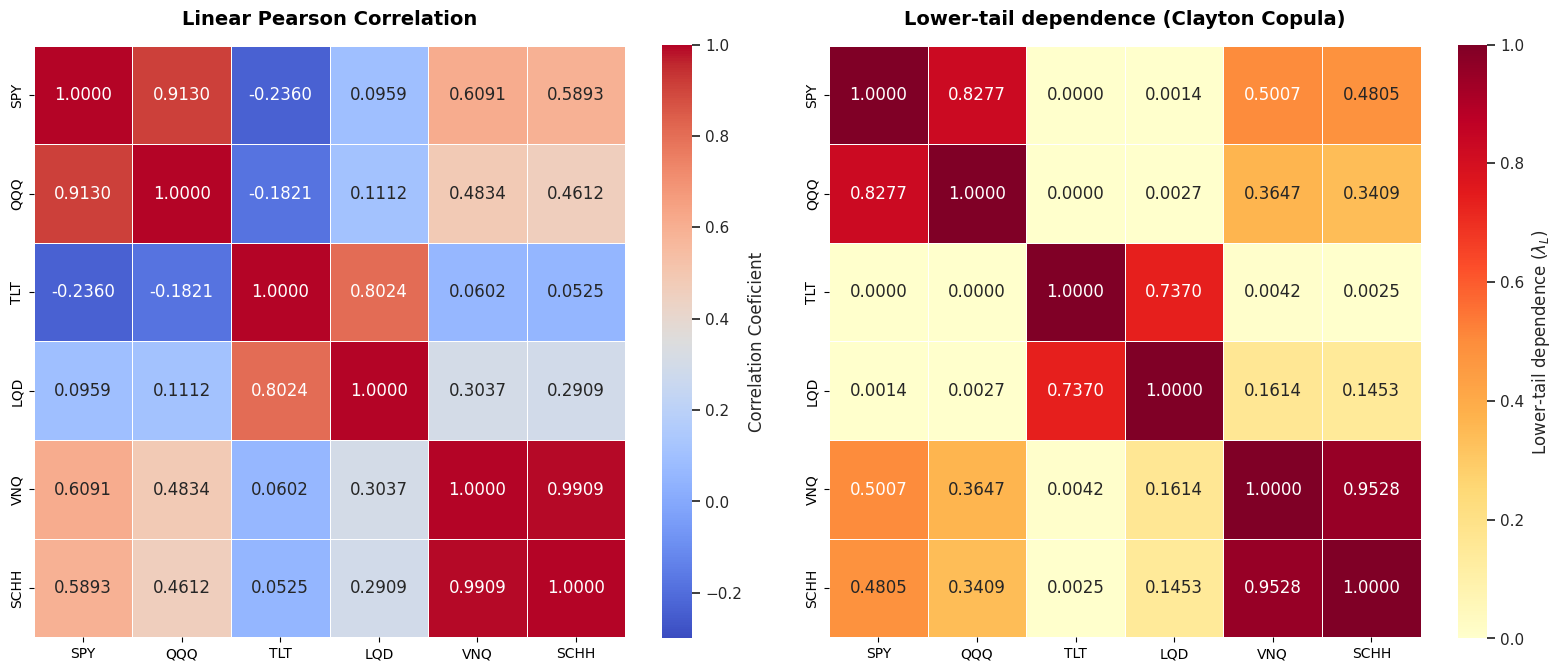

In [19]:
#Creating the heatmap of each matrix

import seaborn as sns

tickers = ["SPY", "QQQ", "TLT", "LQD", "VNQ", "SCHH"]

pearson_data = {
    "SPY": [1.000000, 0.912965, -0.236031, 0.095875, 0.609121, 0.589274],
    "QQQ": [0.912965, 1.000000, -0.182074, 0.111167, 0.483356, 0.461237],
    "TLT": [-0.236031, -0.182074, 1.000000, 0.802373, 0.060203, 0.052544],
    "LQD": [0.095875, 0.111167, 0.802373, 1.000000, 0.303721, 0.290871],
    "VNQ": [0.609121, 0.483356, 0.060203, 0.303721, 1.000000, 0.990933],
    "SCHH": [0.589274, 0.461237, 0.052544, 0.290871, 0.990933, 1.000000],
}

clayton_data = {
    "SPY": [1.0000, 0.8277, 0.0000, 0.0014, 0.5007, 0.4805],
    "QQQ": [0.8277, 1.0000, 0.0000, 0.0027, 0.3647, 0.3409],
    "TLT": [0.0000, 0.0000, 1.0000, 0.7370, 0.0042, 0.0025],
    "LQD": [0.0014, 0.0027, 0.7370, 1.0000, 0.1614, 0.1453],
    "VNQ": [0.5007, 0.3647, 0.0042, 0.1614, 1.0000, 0.9528],
    "SCHH": [0.4805, 0.3409, 0.0025, 0.1453, 0.9528, 1.0000],
}

df_pearson = pd.DataFrame(pearson_data, index=tickers, columns=tickers)
df_clayton = pd.DataFrame(clayton_data, index=tickers, columns=tickers)


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))


sns.set_theme(style="white")
sns.heatmap(
    df_pearson,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=-0.3,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"label": "Correlation Coeficient"},
)
axes[0].set_title(
    "Linear Pearson Correlation",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

sns.heatmap(
    df_clayton,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd",
    vmin=0.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"label": "Lower-tail dependence ($\lambda_L$)"},
)
axes[1].set_title(
    "Lower-tail dependence (Clayton Copula)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()
plt.show()